importar bibliotecas que sejam precisas -> vocês vão ter que ter as bibliotecas instaladas ou no anaconda e depois usar aqui ou instalar mesmo no vosso pc, mas depois podemos ver isto juntas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

carregar o dataset (que tem de estar na mesma pasta que este notebook)

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### ver info toda sobre o dataset (parte 1) -> Estatística descritiva por variável

In [2]:
print(f"Número de colunas: {df.shape[1]}")
print(f"Número de linhas: {df.shape[0]}")
print("\nColunas e tipos de dados:\n")
print(df.dtypes)

print("\n" + "="*60)
print("Contagem de valores por coluna")
print("="*60)

for coluna in df.columns:
    print(f"\n--- {coluna} ---")
    print(f"Valores únicos: {df[coluna].nunique()}")
    print(df[coluna].value_counts(dropna=False))

Número de colunas: 18
Número de linhas: 12330

Colunas e tipos de dados:

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Contagem de valores por coluna

--- Administrative ---
Valores únicos: 27
Administrative
0     5768
1     1354
2     1114
3      915
4      765
5      575
6      432
7      338
8      287
9      225
10     153
11     105
12      86
13      56
14      44
15      38
16      24
17   

### ver info toda sobre o dataset (parte 2) -> Estatística descritiva por variável

In [3]:
from IPython.display import display

print(f"Número de colunas: {df.shape[1]}")
print(f"Número de linhas: {df.shape[0]}\n")

for coluna in df.columns:
    print(f"--- {coluna} (tipo: {df[coluna].dtype}) ---")
    
    tabela = df[coluna].value_counts(dropna=False).reset_index()
    tabela.columns = ['valor', 'contagem']
    tabela['percentagem'] = (tabela['contagem'] / len(df) * 100).round(2)
    
    display(tabela)
    print()

Número de colunas: 18
Número de linhas: 12330

--- Administrative (tipo: int64) ---


,valor,contagem,percentagem
0,0,5768,46.78
1,1,1354,10.98
2,2,1114,9.03
3,3,915,7.42
4,4,765,6.20
5,5,575,4.66
6,6,432,3.50
7,7,338,2.74
8,8,287,2.33
9,9,225,1.82



--- Administrative_Duration (tipo: float64) ---


,valor,contagem,percentagem
0,0.000000,5903,47.88
1,4.000000,56,0.45
2,5.000000,53,0.43
3,7.000000,45,0.36
4,11.000000,42,0.34
...,...,...,...
3330,65.600000,1,0.01
3331,552.200000,1,0.01
3332,206.250000,1,0.01
3333,401.150000,1,0.01



--- Informational (tipo: int64) ---


...

,valor,contagem,percentagem
0,Returning_Visitor,10551,85.57
1,New_Visitor,1694,13.74
2,Other,85,0.69



--- Weekend (tipo: bool) ---


,valor,contagem,percentagem
0,False,9462,76.74
1,True,2868,23.26



--- Revenue (tipo: bool) ---


,valor,contagem,percentagem
0,False,10422,84.53
1,True,1908,15.47


## Duplicados e valores em falta

ver se existem linhas duplicadas (exatamente iguais) e validar se não existem mesmo valores em falta

In [ ]:
# Verificar valores em falta
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Não existem valores em falta.")

# Verificar duplicados
print("\n=== Duplicados ===")
n_duplicados = df.duplicated().sum()
print(f"Número de linhas duplicadas: {n_duplicados}")

=== Missing Values ===
Não existem valores em falta.

=== Duplicados ===
Número de linhas duplicadas: 125


In [8]:
# Identificar todas as linhas envolvidas em duplicação (originais + cópias)
duplicados = df[df.duplicated(keep=False)].copy()

# Criar um ID de grupo para cada conjunto de linhas idênticas
duplicados['grupo_id'] = duplicados.groupby(list(df.columns)).ngroup()

# Ordenar por grupo para ver os pares/conjuntos lado a lado
duplicados = duplicados.sort_values('grupo_id')

print(f"Total de linhas envolvidas em duplicação: {len(duplicados)}")
print(f"Número de grupos de duplicados distintos: {duplicados['grupo_id'].nunique()}")


Total de linhas envolvidas em duplicação: 201
Número de grupos de duplicados distintos: 76


201 linhas no total fazem parte de algum grupo de duplicados (isto inclui a "primeira ocorrência" de cada grupo + todas as cópias repetidas).
Essas 201 linhas distribuem-se por 76 grupos distintos, ou seja, há 76 combinações de valores diferentes que se repetem, cada uma com 2 ou mais linhas idênticas entre si.

## Confirmar desiquilíbrio de Revenue

In [3]:
print("=== Desequilíbrio da variável-alvo (Revenue) ===\n")

contagem = df['Revenue'].value_counts()
percentagem = df['Revenue'].value_counts(normalize=True) * 100

resumo = pd.DataFrame({
    'contagem': contagem,
    'percentagem (%)': percentagem.round(2)
})
display(resumo)

rácio = contagem[False] / contagem[True]
print(f"\nRácio não-compra : compra  ≈  {rácio:.1f} : 1")
print("=> Dataset desequilibrado. A ser considerado no passo de modelação (resampling / class_weight).")

=== Desequilíbrio da variável-alvo (Revenue) ===



,contagem,percentagem (%)
Revenue,,
False,10422,84.53
True,1908,15.47



Rácio não-compra : compra  ≈  5.5 : 1
=> Dataset desequilibrado. A ser considerado no passo de modelação (resampling / class_weight).


## Distribuições (histogramas/boxplots) separadas por Revenue

In [5]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nColunas numéricas: {colunas_numericas}"  )


Colunas numéricas: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


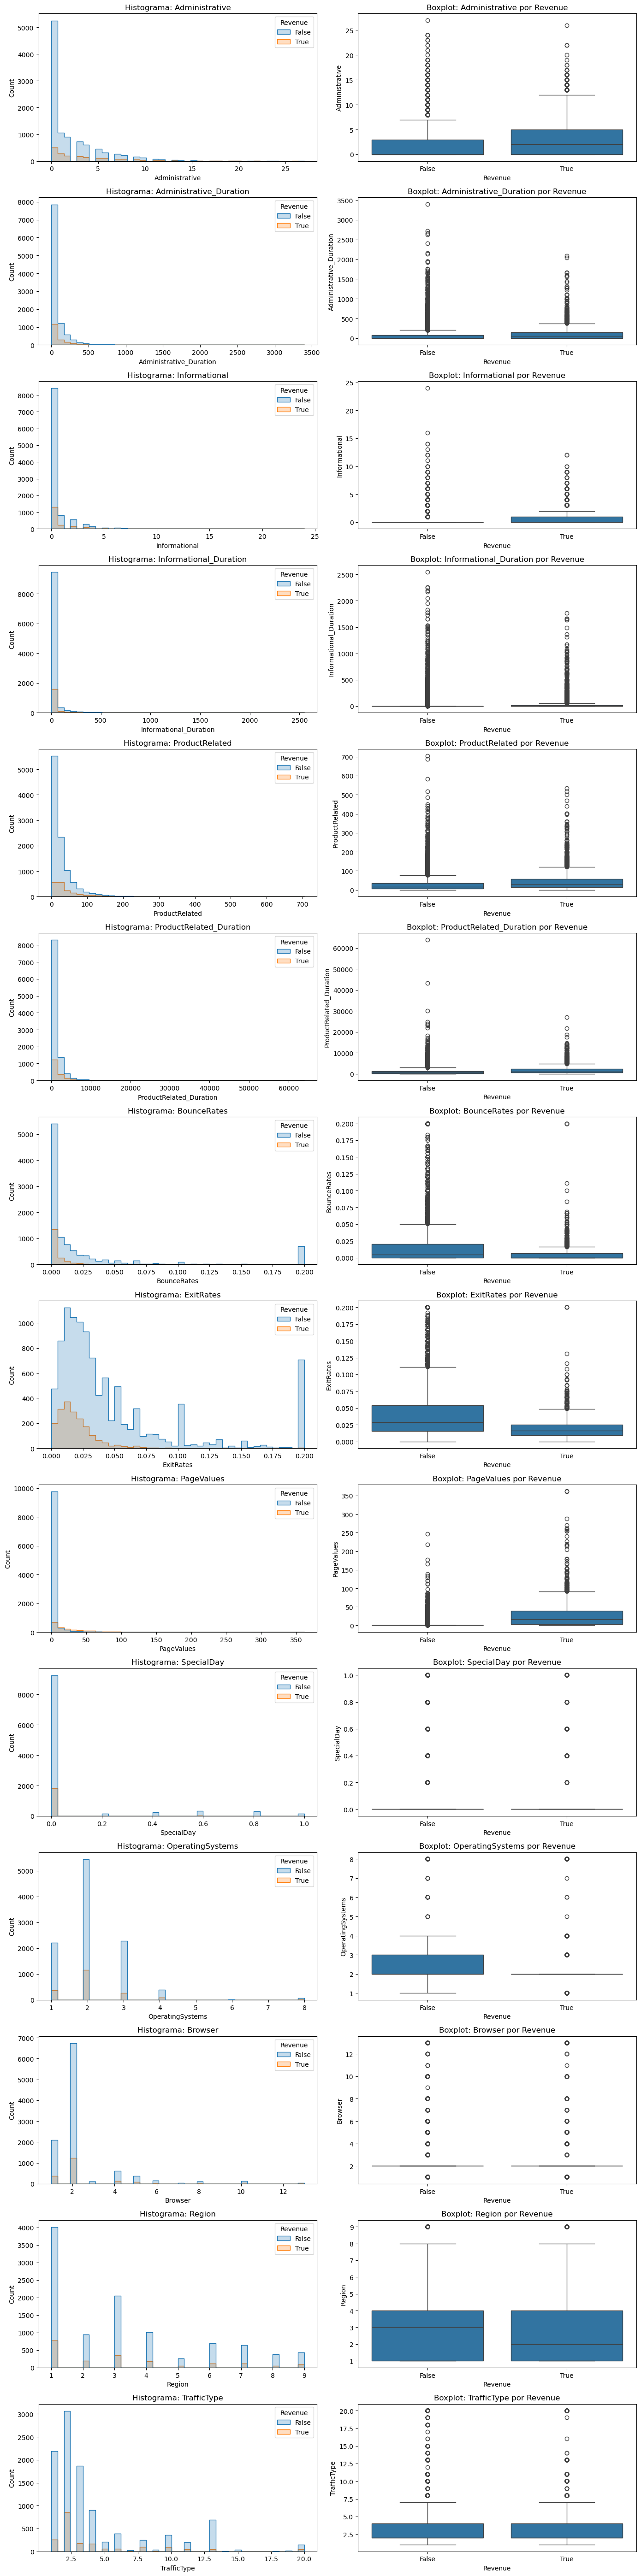

In [ ]:
fig, axes = plt.subplots(len(colunas_numericas), 2, figsize=(14, 4 * len(colunas_numericas)))

for i, col in enumerate(colunas_numericas):
    sns.histplot(data=df, x=col, hue='Revenue', bins=40, kde=False, ax=axes[i, 0], element='step')
    axes[i, 0].set_title(f'Histograma: {col}')

    sns.boxplot(data=df, x='Revenue', y=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot: {col} por Revenue')

plt.tight_layout()
plt.show()

## Heatmap de correlação entre variáveis numéricas

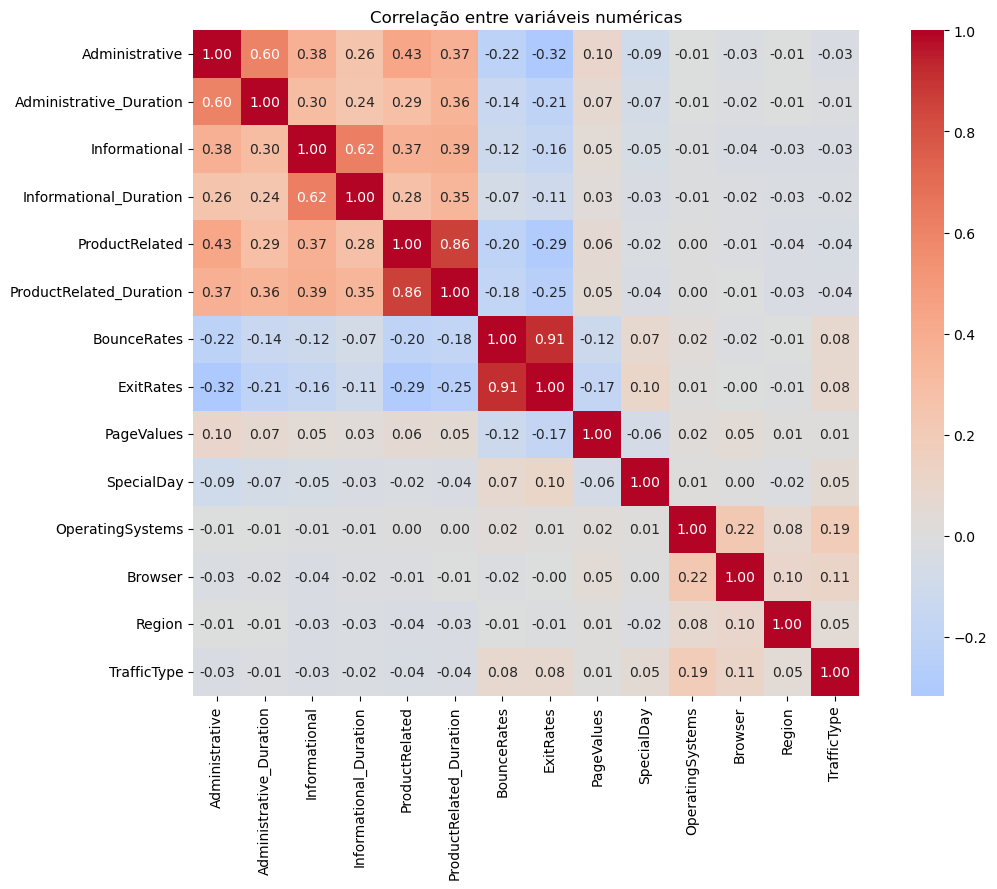


Pares com correlação forte (|r| > 0.6):


BounceRates              ExitRates                  0.913004
ProductRelated_Duration  ProductRelated             0.860927
Informational            Informational_Duration     0.618955
Administrative           Administrative_Duration    0.601583
dtype: float64

In [6]:
plt.figure(figsize=(12, 9))
correlacao = df[colunas_numericas].corr()

sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

print("\nPares com correlação forte (|r| > 0.6):")
pares_fortes = correlacao.abs().unstack().sort_values(ascending=False)
pares_fortes = pares_fortes[(pares_fortes < 1.0) & (pares_fortes > 0.6)]
display(pares_fortes.drop_duplicates())

## Cruzamentos categóricos com Revenue

In [7]:
colunas_categoricas = ['Month', 'VisitorType', 'Weekend', 'Region', 'TrafficType']

for col in colunas_categoricas:
    print(f"\n=== Taxa de conversão por {col} ===")
    tabela = df.groupby(col)['Revenue'].agg(['count', 'mean']).rename(columns={'count': 'n_sessoes', 'mean': 'taxa_conversao'})
    tabela['taxa_conversao (%)'] = (tabela['taxa_conversao'] * 100).round(2)
    tabela = tabela.drop(columns='taxa_conversao').sort_values('taxa_conversao (%)', ascending=False)
    display(tabela)


=== Taxa de conversão por Month ===


,n_sessoes,taxa_conversao (%)
Month,,
Nov,2998,25.35
Oct,549,20.95
Sep,448,19.20
Aug,433,17.55
Jul,432,15.28
Dec,1727,12.51
May,3364,10.85
June,288,10.07
Mar,1907,10.07



=== Taxa de conversão por VisitorType ===


,n_sessoes,taxa_conversao (%)
VisitorType,,
New_Visitor,1694,24.91
Other,85,18.82
Returning_Visitor,10551,13.93



=== Taxa de conversão por Weekend ===


,n_sessoes,taxa_conversao (%)
Weekend,,
True,2868,17.40
False,9462,14.89



=== Taxa de conversão por Region ===


,n_sessoes,taxa_conversao (%)
Region,,
9,511,16.83
2,1136,16.55
5,318,16.35
1,4780,16.13
7,761,15.64
4,1182,14.81
3,2403,14.52
6,805,13.91
8,434,12.90



=== Taxa de conversão por TrafficType ===


,n_sessoes,taxa_conversao (%)
TrafficType,,
16,3,33.33
7,40,30.00
8,343,27.70
20,198,25.25
2,3913,21.65
5,260,21.54
10,450,20.00
11,247,19.03
4,1069,15.43


## Análise de sazonalidade (conversão por mês e SpecialDay)

=== Conversão por mês ===


,n_sessoes,taxa_conversao (%)
Month,,
Feb,184,1.63
Mar,1907,10.07
May,3364,10.85
June,288,10.07
Jul,432,15.28
Aug,433,17.55
Sep,448,19.20
Oct,549,20.95
Nov,2998,25.35


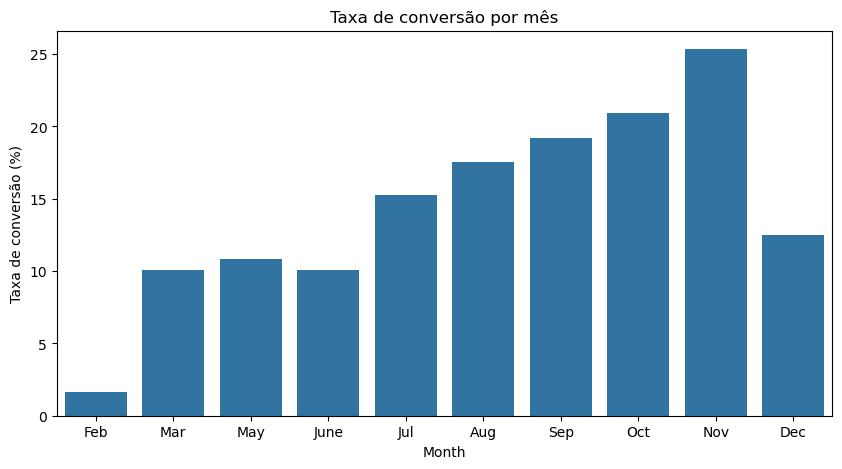


=== Conversão por SpecialDay ===


,n_sessoes,taxa_conversao (%)
SpecialDay,,
0.0,11079,16.53
0.2,178,7.87
0.4,243,5.35
0.6,351,8.26
0.8,325,3.38
1.0,154,6.49


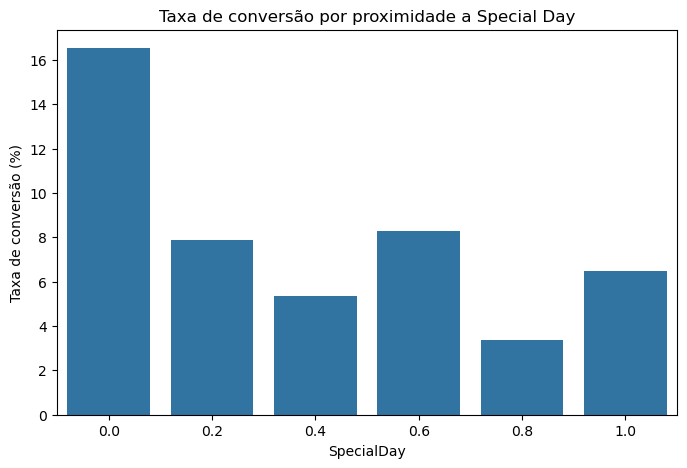

In [8]:
# Conversão por mês
print("=== Conversão por mês ===")
ordem_meses = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
conv_mes = df.groupby('Month')['Revenue'].agg(['count', 'mean']).rename(columns={'count': 'n_sessoes', 'mean': 'taxa_conversao'})
conv_mes['taxa_conversao (%)'] = (conv_mes['taxa_conversao'] * 100).round(2)
conv_mes = conv_mes.reindex([m for m in ordem_meses if m in conv_mes.index])
display(conv_mes.drop(columns='taxa_conversao'))

plt.figure(figsize=(10, 5))
sns.barplot(x=conv_mes.index, y=conv_mes['taxa_conversao (%)'])
plt.title('Taxa de conversão por mês')
plt.ylabel('Taxa de conversão (%)')
plt.show()

# Conversão por proximidade a SpecialDay
print("\n=== Conversão por SpecialDay ===")
conv_special = df.groupby('SpecialDay')['Revenue'].agg(['count', 'mean']).rename(columns={'count': 'n_sessoes', 'mean': 'taxa_conversao'})
conv_special['taxa_conversao (%)'] = (conv_special['taxa_conversao'] * 100).round(2)
display(conv_special.drop(columns='taxa_conversao'))

plt.figure(figsize=(8, 5))
sns.barplot(x=conv_special.index, y=conv_special['taxa_conversao (%)'])
plt.title('Taxa de conversão por proximidade a Special Day')
plt.ylabel('Taxa de conversão (%)')
plt.show()

## Criar variáveis agregadas (tempo total de sessão, total de páginas visitadas)

**Fundamento**  
  
Simplifica informação dispersa: resume 6 variáveis (contagens + durações por categoria) numa medida global de engagement, mais fácil de interpretar.   
  
Reduz redundância: contagem e duração da mesma categoria tendem a estar correlacionadas; agregá-las ajuda a mitigar essa multicolinearidade já identificada.  
  
Torna a hipótese testável diretamente: permite comparar diretamente "engagement total" entre sessões com e sem compra, e serve de base à análise de saturação.  
  
Potencial preditivo: métricas agregadas captam a intensidade geral da sessão de forma mais robusta do que variáveis individuais esparsas.   
  
Facilita comunicação: mais simples de apresentar nas conclusões do que o efeito de 6 variáveis separadas.  
  
**Nota:** as variáveis originais mantêm-se no dataset, as agregadas são complementares, não substitutas, até à fase de feature selection.

### Descrição das novas variáveis
  
**Total_Duration** soma do tempo total (em segundos) que o visitante passou na sessão, agregando as três categorias de página: Administrative_Duration + Informational_Duration + ProductRelated_Duration. Representa o tempo global de permanência do utilizador no site durante a sessão, independentemente do tipo de página visitada.  
  
**Total_Pages** soma do número total de páginas visitadas na sessão, agregando as três categorias: Administrative + Informational + ProductRelated. Representa o volume global de navegação do utilizador, ou seja, quantas páginas diferentes visitou ao todo, independentemente da categoria.  
  
Ambas as variáveis funcionam como proxies agregadas de engagement geral da sessão, complementando as variáveis originais (que estão desagregadas por categoria de página).

=== Novas variáveis agregadas ===


,Total_Duration,Total_Pages
count,12330.000000,12330.000000
mean,1310.037228,34.550203
std,2037.801702,46.514053
min,0.000000,0.000000
25%,222.000000,8.000000
50%,680.000000,20.000000
75%,1626.908333,42.000000
max,69921.647230,746.000000



=== Comparação por grupo (Revenue) ===


,Total_Duration,Total_Pages
Revenue,,
False,1173.96,31.28
True,2053.30,52.39


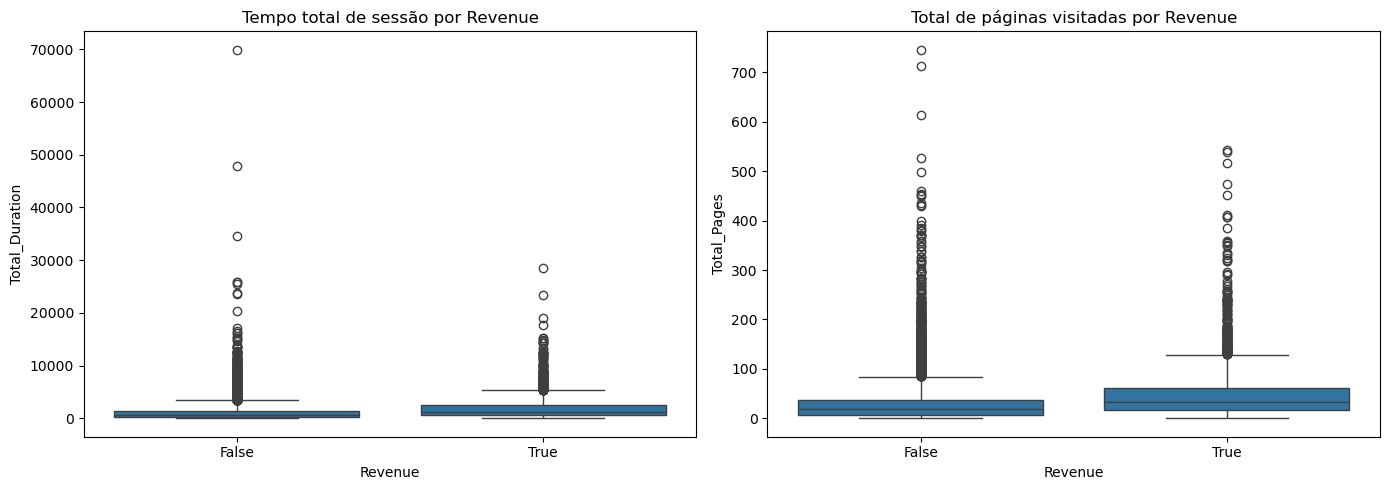

In [9]:
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']
df['Total_Pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

print("=== Novas variáveis agregadas ===")
display(df[['Total_Duration', 'Total_Pages', 'Revenue']].describe())

print("\n=== Comparação por grupo (Revenue) ===")
display(df.groupby('Revenue')[['Total_Duration', 'Total_Pages']].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Revenue', y='Total_Duration', ax=axes[0])
axes[0].set_title('Tempo total de sessão por Revenue')
sns.boxplot(data=df, x='Revenue', y='Total_Pages', ax=axes[1])
axes[1].set_title('Total de páginas visitadas por Revenue')
plt.tight_layout()
plt.show()

## Explorar hipótese de "saturação" de engagement

=== Taxa de conversão por nível de engagement (Total_Pages, em decis) ===


,n_sessoes,taxa_conversao (%)
Pages_Bin,,
"(-0.001, 3.0]",1370,2.19
"(3.0, 7.0]",1386,7.14
"(7.0, 11.0]",1203,10.31
"(11.0, 15.0]",1136,13.64
"(15.0, 20.0]",1156,15.31
"(20.0, 27.0]",1265,17.71
"(27.0, 36.0]",1151,21.37
"(36.0, 50.0]",1258,19.32
"(50.0, 79.1]",1172,21.93


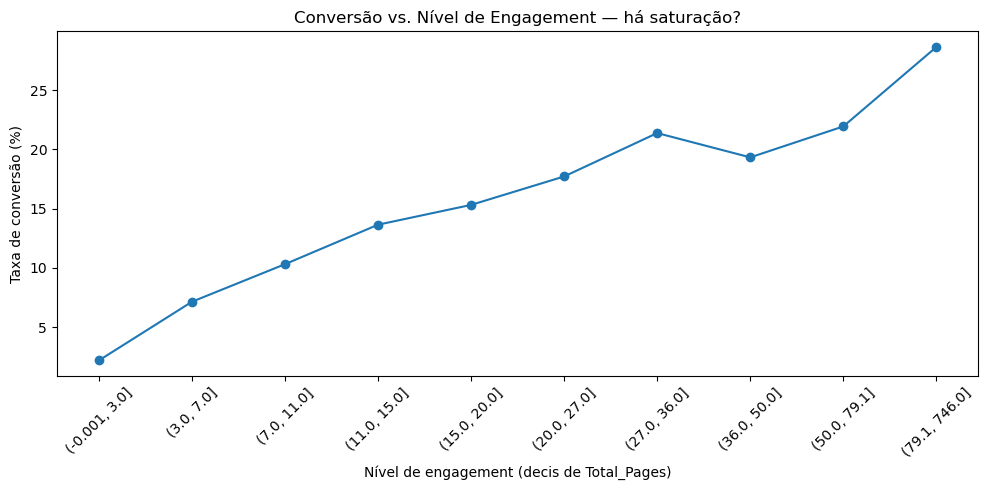

In [11]:
# Agrupar Total_Pages em bins para ver se a taxa de conversão sobe e depois desce
df['Pages_Bin'] = pd.qcut(df['Total_Pages'], q=10, duplicates='drop')

saturacao = df.groupby('Pages_Bin', observed=True)['Revenue'].agg(['count', 'mean']).rename(columns={'count': 'n_sessoes', 'mean': 'taxa_conversao'})
saturacao['taxa_conversao (%)'] = (saturacao['taxa_conversao'] * 100).round(2)

print("=== Taxa de conversão por nível de engagement (Total_Pages, em decis) ===")
display(saturacao.drop(columns='taxa_conversao'))

plt.figure(figsize=(10, 5))
plt.plot(range(len(saturacao)), saturacao['taxa_conversao (%)'], marker='o')
plt.xticks(range(len(saturacao)), [str(i) for i in saturacao.index], rotation=45)
plt.xlabel('Nível de engagement (decis de Total_Pages)')
plt.ylabel('Taxa de conversão (%)')
plt.title('Conversão vs. Nível de Engagement — há saturação?')
plt.tight_layout()
plt.show()


**O que significa "saturação" neste contexto**  
  
Saturação significaria que, a partir de um certo nível de navegação, visitar mais páginas deixa de aumentar (ou começa a diminuir) a probabilidade de compra — ou seja, um "efeito de fadiga": o utilizador navega tanto que acaba por desistir em vez de comprar. Isso apareceria no gráfico como a taxa de conversão a subir e depois a estabilizar ou cair nos decis mais altos.  
  
**Conclusão**  
  
Não há evidência de saturação. A taxa de conversão sobe de forma quase monótona com o número de páginas visitadas — de ~2% no decil mais baixo até quase 29% no decil mais alto. Há uma pequena quebra no decil (36.0, 50.0], mas é ligeira e a tendência recupera logo a seguir, portanto não é suficiente para indicar um padrão real de saturação.  
  
Interpretação prática: quanto mais páginas uma sessão visita, maior a probabilidade de terminar em compra — sem sinal de que navegar "demasiado" prejudique a conversão, pelo menos dentro do intervalo observado neste dataset. Isto reforça Total_Pages (e, por extensão, o engagement geral) como um bom candidato a variável preditiva.